# ML Project

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import all datasets

teams = pd.read_csv('../dataset_cleaned/teams.csv')
teams_post = pd.read_csv('../dataset_cleaned/teams_post.csv')
awards_players = pd.read_csv('../dataset_cleaned/awards_players.csv')
series_post = pd.read_csv('../dataset_cleaned/series_post.csv')
players = pd.read_csv('../dataset_cleaned/players.csv')
players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
coaches = pd.read_csv('../dataset_cleaned/coaches.csv')


## Feature Engineering

### Features for the First Problem

In [33]:
# Calculate the number of player awards per team each year
if 'player_awards' in teams.columns:
    teams = teams.drop(columns=['player_awards'])
filtered_awards = awards_players[awards_players['award'] != "Coach of the Year"].copy()
award_counts = filtered_awards.groupby(['playerID', 'year']).size().reset_index(name='player_awards')
player_team_awards = pd.merge(award_counts, players_teams, on=['playerID', 'year'], how='inner')
player_team_awards = player_team_awards.dropna(subset=['tmID'])
team_awards = player_team_awards.groupby(['tmID', 'year'])['player_awards'].sum().reset_index()
teams = pd.merge(teams, team_awards[['tmID', 'year', 'player_awards']], on=['tmID', 'year'], how='left')
teams['player_awards'] = teams['player_awards'].fillna(0).astype(int)

# Measures how much a team outscores its opponents per game
teams["net_rating"] = (teams["o_pts"] - teams["d_pts"]) / teams["GP"]

teams["off_eff"] = teams["o_pts"] / teams["o_fga"]   # points per field goal attempt
teams["def_eff"] = teams["d_pts"] / teams["d_fga"]   # points allowed per opponent FGA

# Measures how effectively the team scores compared to what they allow
teams["eff_diff"] = teams["off_eff"] - teams["def_eff"]

# Calculate the Home vs Away Win Ratio (small gap means consistency)
teams["home_win_pct"] = teams["homeW"] / (teams["homeW"] + teams["homeL"])
teams["away_win_pct"] = teams["awayW"] / (teams["awayW"] + teams["awayL"])
teams["home_away_balance"] = teams["away_win_pct"] - teams["home_win_pct"]

# Calculate the difference between the turnovers of the opponents and the turnovers of the team
teams["to_dif"] = teams["d_to"] - teams["o_to"]

# Calculate the difference between the rebounds gained by the team and the ones gained by the opponents
teams["reb_dif"] = teams["o_reb"] - teams["d_reb"]

# Calculate the offensive rebound difference (extra scoring opportunities created by the team)
teams["off_reb_dif"] = teams["o_oreb"] - teams["d_dreb"]

# Calculate the defensive rebound difference (how well the team prevents second-chance points)
teams["def_reb_dif"] = teams["o_dreb"] - teams["d_oreb"]

# Calculate the percentage of all total rebounds captured by the team
teams["reb_pct"] = teams["o_reb"] / (teams["o_reb"] + teams["d_reb"])

# Calculate the percentage of offensive rebounds captured by the team (offensive efficiency)
teams["off_reb_pct"] = teams["o_oreb"] / (teams["o_oreb"] + teams["d_dreb"])

# Calculate the percentage of defensive rebounds captured by the team (defensive efficiency)
teams["def_reb_pct"] = teams["o_dreb"] / (teams["o_dreb"] + teams["d_oreb"])

# Calculate the percentage of conference wins per team
teams["conf_win_pct"] = teams["confW"] / (teams["confW"] + teams["confL"])

# Calculate the difference in assists between the team and its opponents
teams["ast_dif"] = teams["o_asts"] - teams["d_asts"]

# Calculate the difference in steals between the team and its opponents
teams["stl_dif"] = teams["o_stl"] - teams["d_stl"]

# Calculate the difference in blocks between the team and its opponents
teams["blk_dif"] = teams["o_blk"] - teams["d_blk"]

# Calculate the difference in personal fouls committed by the team and the opponent
teams["pf_dif"] = teams["o_pf"] - teams["d_pf"]

# Calculate the assist-to-turnover ratio (assists to turnovers ratio) for the team
teams["ast_to_to"] = teams["o_asts"] / (teams["o_to"] + 1e-5)

# Calculate the steal-to-turnover ratio (steals to turnovers ratio) for the team
teams["stl_to_to"] = teams["o_stl"] / (teams["o_to"] + 1e-5)

# Calculate the block-to-turnover ratio (blocks to turnovers ratio) for the team
teams["blk_to_to"] = teams["o_blk"] / (teams["o_to"] + 1e-5)

# Calculate the number of coach awards per team each year
if 'coach_awards' in teams.columns:
    teams = teams.drop(columns=['coach_awards'])
coach_awards = awards_players[awards_players['award'] == 'Coach of the Year'].copy()
coach_awards_count = coach_awards.groupby(['playerID', 'year']).size().reset_index(name='coach_awards')
coach_awards_with_team = pd.merge(coach_awards_count, coaches, left_on=['playerID', 'year'], right_on=['coachID', 'year'], how='inner')
coach_team_awards = coach_awards_with_team[['tmID', 'year', 'coach_awards']].drop_duplicates()
teams = pd.merge(teams, coach_team_awards, on=['tmID', 'year'], how='left')
teams['coach_awards'] = teams['coach_awards'].fillna(0).astype(int)

# Calculate win percentage
teams["win_pct"] = teams["won"] / (teams["won"] + teams["lost"])

# Calculate offensive field goal percentage
teams["fg_pct"] = teams["o_fgm"] / teams["o_fga"]

# Calculate 3 points made percentage
teams["3p_pct"] = teams["o_3pm"] / (teams["o_3pm"] + teams["o_3pa"])

# Calculate point average (made points vs allowed points)
teams["pa_pct"] = teams["o_pts"] / (teams["o_pts"] + teams["d_pts"])

# Calculate free throw percentage (offensive free throws made vs. offensive free throws attempted)
teams["ft_pct"] = teams["o_ftm"] / (teams["o_ftm"] + teams["o_fta"])

# Effective goal percentage
teams["efg_pct"] = (teams["o_fgm"] + teams["o_3pm"] + teams["o_ftm"]) / (teams["o_fga"] + teams["o_fta"] + teams["o_3pa"])

# Turnover percentage (measures ball control efficiency)
teams["tov_pct"] = teams["o_to"] / (teams["o_fga"] + 0.44 * teams["o_fta"] + teams["o_to"])

# Offensive rebounding percentage (measures second-chance opportunities)
teams["orb_pct"] = teams["o_oreb"] / (teams["o_oreb"] + teams["d_dreb"])

# Free throw rate (measures ability to get to the foul line)
teams["ftr"] = teams["o_ftm"] / teams["o_fta"]

# Estimate total possessions for the team
teams["poss"] = 0.96 * (teams["o_fga"] + teams["o_to"] + 0.44 * teams["o_fta"] - teams["o_oreb"])

# Estimate total possessions for opponents
teams["opp_poss"] = 0.96 * (teams["d_fga"] + teams["d_to"] + 0.44 * teams["d_fta"] - teams["d_oreb"])

# Pace (measures game tempo - possessions per game)
teams["pace"] = (teams["poss"] + teams["opp_poss"]) / (2 * teams["GP"])

# Offensive efficiency (points scored per possession)
teams["pts_per_poss"] = teams["o_pts"] / teams["poss"]

# Defensive efficiency (points allowed per possession)
teams["opp_pts_per_poss"] = teams["d_pts"] / teams["opp_poss"]

# Assist ratio (percentage of made field goals that were assisted)
teams["ast_ratio"] = teams["o_asts"] / teams["o_fgm"]

# True shooting percentage (comprehensive shooting efficiency metric)
teams["ts_pct"] = teams["o_pts"] / (2 * (teams["o_fga"] + 0.44 * teams["o_fta"]))

# Efficiency adjusted for pace
teams["eff_x_pace"] = teams["eff_diff"] * teams["pace"]

# Combined rebounding and playmaking advantage
teams["reb_x_ast"] = teams["reb_dif"] * teams["ast_dif"]

# Opponent's effective goal percentage (lower is better for defense)
teams["opp_efg_pct"] = (teams["d_fgm"] + teams["d_3pm"] + teams["d_ftm"]) / (teams["d_fga"] + teams["d_fta"] + teams["d_3pa"])

# Opponent's turnover percentage (forcing turnovers is key)
teams["opp_tov_pct"] = teams["d_to"] / (teams["d_fga"] + 0.44 * teams["d_fta"] + teams["d_to"])

# Opponent's free throw rate (limiting free throws)
teams["opp_ftr"] = teams["d_ftm"] / teams["d_fta"]

# Opponent's true shooting percentage
teams["opp_ts_pct"] = teams["d_pts"] / (2 * (teams["d_fga"] + 0.44 * teams["d_fta"]))

# Offensive Four Factors score
teams["off_four_factors"] = (0.40 * teams["efg_pct"] + 0.25 * (1 - teams["tov_pct"]) + 0.20 * teams["orb_pct"] + 0.15 * teams["ftr"])

# Defensive Four Factors score (lower opponent metrics are better)
teams["def_four_factors"] = (0.40 * (1 - teams["opp_efg_pct"]) + 0.25 * teams["opp_tov_pct"] + 0.20 * teams["def_reb_pct"] + 0.15 * (1 - teams["opp_ftr"]))

# Net Four Factors (offensive advantage minus defensive disadvantage)
teams["net_four_factors"] = teams["off_four_factors"] - (1 - teams["def_four_factors"])

# Three-point attempt rate
teams["three_pt_rate"] = teams["o_3pa"] / teams["o_fga"]

# Points from three-pointers ratio
teams["pts_from_three"] = (teams["o_3pm"] * 3) / teams["o_pts"]

# Steal percentage (steals per opponent possession)
teams["stl_pct"] = teams["o_stl"] / teams["opp_poss"]

# Block percentage (blocks per opponent possession)
teams["blk_pct"] = teams["o_blk"] / teams["opp_poss"]

# Defensive activity rate (steals + blocks per game)
teams["def_activity"] = (teams["o_stl"] + teams["o_blk"]) / teams["GP"]

# Pythagorean win percentage (expected wins based on points scored/allowed)
teams["pyth_wins"] = (teams["o_pts"] ** 13.91) / (teams["o_pts"] ** 13.91 + teams["d_pts"] ** 13.91)

# Win differential (actual wins vs expected wins)
teams["win_differential"] = teams["win_pct"] - teams["pyth_wins"]

# Conference strength indicator (conference win percentage vs overall)
teams["conf_strength"] = teams["conf_win_pct"] / (teams["win_pct"] + 1e-5)


### Features for the Third Problem

In [51]:
individual_awards = awards_players['award'].drop_duplicates()

coy_awards = awards_players[awards_players['award'] == 'Coach of the Year'].copy()
coy_awards['won_coy'] = 1

mip_awards = awards_players[awards_players['award'] == 'Most Improved Player'].copy()
mip_awards['won_mip'] = 1

mvp_awards = awards_players[awards_players['award'] == 'Most Valuable Player'].copy()
mvp_awards['won_mvp'] = 1

individual_awards

0         All-Star Game Most Valuable Player
8                          Coach of the Year
18              Defensive Player of the Year
28            Kim Perrot Sportsmanship Award
38                      Most Improved Player
47                      Most Valuable Player
57                        Rookie of the Year
67                   Sixth Woman of the Year
70          WNBA Finals Most Valuable Player
80                      WNBA All-Decade Team
90    WNBA All Decade Team Honorable Mention
Name: award, dtype: object

#### Features for Coach of the Year Award

In [35]:
# Features for Coach of the Year Award
coaches_features = coaches.copy()

# Basic performance coach metrics
coaches_features['win_percentage'] = coaches_features['won'] / (coaches_features['won'] + coaches_features['lost'])
coaches_features['total_games'] = coaches_features['won'] + coaches_features['lost']
coaches_features['playoff_games'] = coaches_features['post_wins'] + coaches_features['post_losses']
coaches_features['playoff_win_pct'] = np.where(
    coaches_features['playoff_games'] > 0,
    coaches_features['post_wins'] / coaches_features['playoff_games'],
    0
)
# Merge with team features data
coaches_full = coaches_features.merge(teams, on=['year', 'tmID'], how='left', suffixes=('_coach', '_team'))

# Team performance features
coaches_full['point_differential'] = coaches_full['o_pts'] - coaches_full['d_pts']
coaches_full['conference_win_pct'] = coaches_full['confW'] / (coaches_full['confW'] + coaches_full['confL'])
coaches_full['home_advantage'] = coaches_full['homeW'] - coaches_full['awayW']
coaches_full['home_win_pct'] = coaches_full['homeW'] / (coaches_full['homeW'] + coaches_full['homeL'])
coaches_full['away_win_pct'] = coaches_full['awayW'] / (coaches_full['awayW'] + coaches_full['awayL'])
coaches_full['made_playoffs'] = (coaches_full['playoff'] == 'Y').astype(int)
coaches_full['offensive_efficiency'] = coaches_full['o_pts'] / coaches_full['GP']
coaches_full['defensive_efficiency'] = coaches_full['d_pts'] / coaches_full['GP']

# Calculate Additional Features
coaches_full = coaches_full.sort_values(['coachID', 'tmID', 'year'])
# Previous year for same coach-team
coaches_full['prev_year_wins'] = coaches_full.groupby(['coachID', 'tmID'])['won_coach'].shift(1)
coaches_full['prev_year_win_pct'] = coaches_full.groupby(['coachID', 'tmID'])['win_percentage'].shift(1)
coaches_full['win_improvement'] = coaches_full['won_coach'] - coaches_full['prev_year_wins']
coaches_full['win_pct_improvement'] = coaches_full['win_percentage'] - coaches_full['prev_year_win_pct']

# Previous year team performance (any coach)
team_prev_wins = teams[['year', 'tmID', 'won']].copy()
team_prev_wins['year'] = team_prev_wins['year'] + 1
team_prev_wins.columns = ['year', 'tmID', 'team_prev_wins']
coaches_full = coaches_full.merge(team_prev_wins, on=['year', 'tmID'], how='left')
coaches_full['team_win_improvement'] = coaches_full['won_coach'] - coaches_full['team_prev_wins']

# Add Target Variable
coaches_full = coaches_full.merge(
    coy_awards[['playerID', 'year', 'won_coy']],
    left_on=['coachID', 'year'],
    right_on=['playerID', 'year'],
    how='left'
)
coaches_full['won_coy'] = coaches_full['won_coy'].fillna(0).astype(int)




#### Features for Most Improved Player Award

In [36]:
# Features for Most Improved Player Award
player_features = players_teams.copy()

# Calculate per-game statistics
player_features['ppg'] = player_features['points'] / player_features['GP']
player_features['rpg'] = player_features['rebounds'] / player_features['GP']
player_features['apg'] = player_features['assists'] / player_features['GP']
player_features['spg'] = player_features['steals'] / player_features['GP']
player_features['bpg'] = player_features['blocks'] / player_features['GP']
player_features['mpg'] = player_features['minutes'] / player_features['GP']
player_features['topg'] = player_features['turnovers'] / player_features['GP']

# Calculate shooting percentages
player_features['fg_pct'] = np.where(
    player_features['fgAttempted'] > 0,
    player_features['fgMade'] / player_features['fgAttempted'],
    0
)
player_features['ft_pct'] = np.where(
    player_features['ftAttempted'] > 0,
    player_features['ftMade'] / player_features['ftAttempted'],
    0
)
player_features['three_pct'] = np.where(
    player_features['threeAttempted'] > 0,
    player_features['threeMade'] / player_features['threeAttempted'],
    0
)

# Advanced metrics
player_features['usage_rate'] = (player_features['fgAttempted'] + 
                                  0.44 * player_features['ftAttempted'] + 
                                  player_features['turnovers']) / player_features['minutes']

player_features['true_shooting'] = np.where(
    (player_features['fgAttempted'] + 0.44 * player_features['ftAttempted']) > 0,
    player_features['points'] / (2 * (player_features['fgAttempted'] + 0.44 * player_features['ftAttempted'])),
    0
)

player_features['ast_to_ratio'] = np.where(
    player_features['turnovers'] > 0,
    player_features['assists'] / player_features['turnovers'],
    player_features['assists']
)

player_features['made_playoffs'] = (player_features['PostGP'] > 0).astype(int)

# Merge with player bio data
player_features = player_features.merge(
    players[['bioID', 'pos', 'height', 'weight']],
    left_on='playerID',
    right_on='bioID',
    how='left'
)

# Calculate improvement features
player_features = player_features.sort_values(['playerID', 'year'])

# Previous year stats
prev_stats = ['ppg', 'rpg', 'apg', 'spg', 'bpg', 'mpg', 'GP', 'GS', 
              'fg_pct', 'ft_pct', 'three_pct', 'true_shooting', 'usage_rate']

for stat in prev_stats:
    player_features[f'prev_{stat}'] = player_features.groupby('playerID')[stat].shift(1)
    player_features[f'{stat}_improvement'] = player_features[stat] - player_features[f'prev_{stat}']

# Calculate percentage improvements for key stats
for stat in ['ppg', 'rpg', 'apg', 'mpg']:
    player_features[f'{stat}_pct_change'] = np.where(
        player_features[f'prev_{stat}'] > 0,
        (player_features[stat] - player_features[f'prev_{stat}']) / player_features[f'prev_{stat}'] * 100,
        0
    )

# Games started improvement (role expansion indicator)
player_features['gs_improvement'] = player_features['GS'] - player_features['prev_GS']

# Merge with team data features
teams_subset = teams[['year', 'tmID', 'won', 'lost', 'playoff', 'rank', 'confID']].copy()
player_features = player_features.merge(teams_subset, on=['year', 'tmID'], how='left')
player_features['team_win_pct'] = player_features['won'] / (player_features['won'] + player_features['lost'])

# Add Target Variable
player_features = player_features.merge(
    mip_awards[['playerID', 'year', 'won_mip']],
    on=['playerID', 'year'],
    how='left'
)
player_features['won_mip'] = player_features['won_mip'].fillna(0).astype(int)


#### Features for Most Valuable Player Award

In [52]:
player_features = players_teams.copy()

# Calculate per-game statistics
player_features['ppg'] = player_features['points'] / player_features['GP']
player_features['rpg'] = player_features['rebounds'] / player_features['GP']
player_features['apg'] = player_features['assists'] / player_features['GP']
player_features['spg'] = player_features['steals'] / player_features['GP']
player_features['bpg'] = player_features['blocks'] / player_features['GP']
player_features['mpg'] = player_features['minutes'] / player_features['GP']
player_features['topg'] = player_features['turnovers'] / player_features['GP']

# Calculate shooting percentages
player_features['fg_pct'] = np.where(
    player_features['fgAttempted'] > 0,
    player_features['fgMade'] / player_features['fgAttempted'],
    0
)
player_features['ft_pct'] = np.where(
    player_features['ftAttempted'] > 0,
    player_features['ftMade'] / player_features['ftAttempted'],
    0
)
player_features['three_pct'] = np.where(
    player_features['threeAttempted'] > 0,
    player_features['threeMade'] / player_features['threeAttempted'],
    0
)

# Advanced metrics
player_features['usage_rate'] = np.where(
    player_features['minutes'] > 0,
    (player_features['fgAttempted'] + 0.44 * player_features['ftAttempted'] + 
     player_features['turnovers']) / player_features['minutes'],
    0
)

player_features['true_shooting'] = np.where(
    (player_features['fgAttempted'] + 0.44 * player_features['ftAttempted']) > 0,
    player_features['points'] / (2 * (player_features['fgAttempted'] + 
                                       0.44 * player_features['ftAttempted'])),
    0
)

player_features['ast_to_ratio'] = np.where(
    player_features['turnovers'] > 0,
    player_features['assists'] / player_features['turnovers'],
    player_features['assists']
)

# Player efficiency rating approximation
player_features['per_approx'] = (
    player_features['points'] + 
    player_features['rebounds'] + 
    player_features['assists'] + 
    player_features['steals'] + 
    player_features['blocks'] - 
    player_features['turnovers'] - 
    (player_features['fgAttempted'] - player_features['fgMade']) -
    (player_features['ftAttempted'] - player_features['ftMade'])
) / player_features['GP']

# Playoff stats
player_features['made_playoffs'] = (player_features['PostGP'] > 0).astype(int)
player_features['playoff_ppg'] = np.where(
    player_features['PostGP'] > 0,
    player_features['PostPoints'] / player_features['PostGP'],
    0
)
player_features['playoff_rpg'] = np.where(
    player_features['PostGP'] > 0,
    player_features['PostRebounds'] / player_features['PostGP'],
    0
)
player_features['playoff_apg'] = np.where(
    player_features['PostGP'] > 0,
    player_features['PostAssists'] / player_features['PostGP'],
    0
)

# Merge with player bio data
player_features = player_features.merge(
    players[['bioID', 'pos', 'height', 'weight']],
    left_on='playerID',
    right_on='bioID',
    how='left'
)

# Calculate Previous Year Statistics
player_features = player_features.sort_values(['playerID', 'year'])

# Previous year stats
prev_stats = ['ppg', 'rpg', 'apg', 'spg', 'bpg', 'mpg', 'per_approx',
              'fg_pct', 'ft_pct', 'three_pct', 'true_shooting', 'usage_rate']

for stat in prev_stats:
    player_features[f'prev_{stat}'] = player_features.groupby('playerID')[stat].shift(1)
    player_features[f'{stat}_improvement'] = player_features[stat] - player_features[f'prev_{stat}']

# Consistency metric (experience)
player_features['years_experience'] = player_features.groupby('playerID').cumcount()

# Merge with team data features
teams_subset = teams[['year', 'tmID', 'won', 'lost', 'playoff', 'rank', 
                       'confID', 'o_pts', 'd_pts']].copy()
player_features = player_features.merge(teams_subset, on=['year', 'tmID'], how='left')

player_features['team_win_pct'] = player_features['won'] / (player_features['won'] + player_features['lost'])
player_features['team_point_diff'] = player_features['o_pts'] - player_features['d_pts']

# Add Target Variable
player_features = player_features.merge(
    mvp_awards[['playerID', 'year', 'won_mvp']],
    on=['playerID', 'year'],
    how='left'
)
player_features['won_mvp'] = player_features['won_mvp'].fillna(0).astype(int)


## Feature Selection

### Features for the First Problem

In [37]:
feature_selection_columns = [
    'player_awards',
    'net_rating',
    'off_eff',
    'def_eff',
    'eff_diff',
    'home_win_pct',
    'away_win_pct',
    'home_away_balance',
    'to_dif',
    'reb_dif',
    'off_reb_dif',
    'def_reb_dif',
    'reb_pct',
    'off_reb_pct',
    'def_reb_pct',
    'conf_win_pct',
    'ast_dif',
    'stl_dif',
    'blk_dif',
    'pf_dif',
    'ast_to_to',
    'stl_to_to',
    'blk_to_to',
    'coach_awards',
    'win_pct',
    'fg_pct',
    '3p_pct',
    'pa_pct',
    'ft_pct',
    'efg_pct',
    'tov_pct',
    'orb_pct',
    'ftr',
    'poss',
    'opp_poss',
    'pace',
    'pts_per_poss',
    'opp_pts_per_poss',
    'ast_ratio',
    'ts_pct',
    'eff_x_pace',
    'reb_x_ast',
    'opp_efg_pct',
    'opp_tov_pct',
    'opp_ftr',
    'opp_ts_pct',
    'off_four_factors',
    'def_four_factors',
    'net_four_factors',
    'three_pt_rate',
    'pts_from_three',
    'stl_pct',
    'blk_pct',
    'def_activity',
    'pyth_wins',
    'win_differential',
    'conf_strength'
]

teams[feature_selection_columns].head(10)

# Correlations between features and target variable (rank)
CORR_THRESHOLD = 0.3

corr = teams[["rank"] + feature_selection_columns].corr()

# Filter out all features with low correlation given the correlation threshold
strong_corr = corr["rank"][corr["rank"].abs() >= CORR_THRESHOLD]

strong_corr.sort_values()


win_pct            -0.887239
conf_win_pct       -0.868701
pyth_wins          -0.831929
pa_pct             -0.811704
net_rating         -0.810810
home_win_pct       -0.792679
away_win_pct       -0.765164
net_four_factors   -0.717112
eff_x_pace         -0.700264
eff_diff           -0.697435
def_four_factors   -0.619541
ast_dif            -0.575608
pts_per_poss       -0.564497
fg_pct             -0.529026
ts_pct             -0.513849
efg_pct            -0.505535
off_eff            -0.497779
off_four_factors   -0.494128
player_awards      -0.455101
reb_pct            -0.430791
def_reb_dif        -0.424939
reb_dif            -0.424061
ast_to_to          -0.407428
def_reb_pct        -0.372688
blk_dif            -0.367617
coach_awards       -0.314351
pf_dif              0.305900
def_eff             0.557654
opp_pts_per_poss    0.566154
opp_ts_pct          0.576598
opp_efg_pct         0.616676
rank                1.000000
Name: rank, dtype: float64

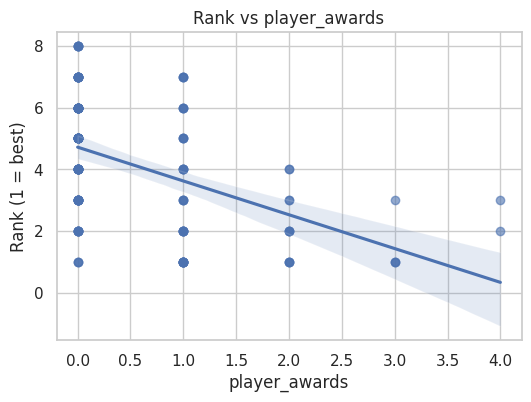

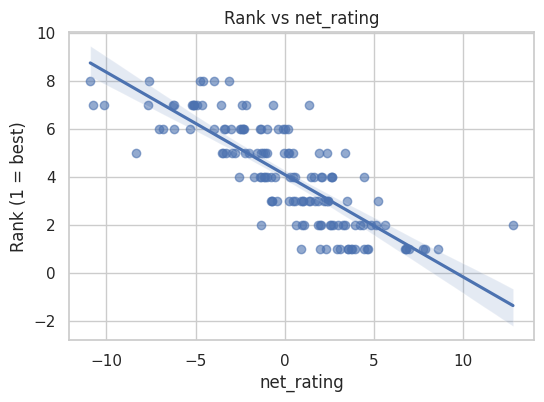

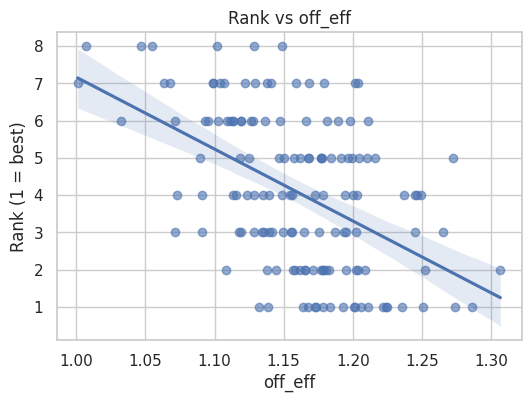

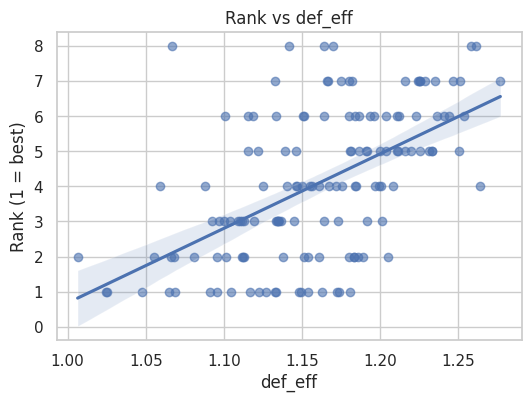

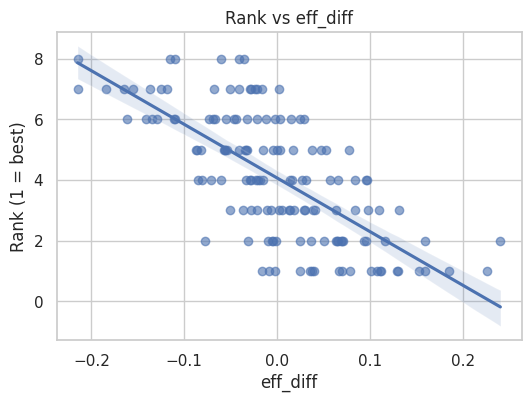

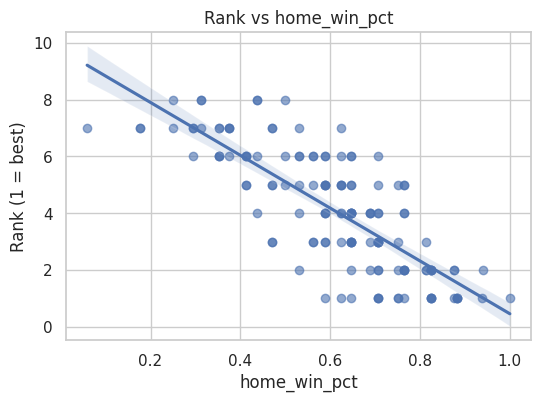

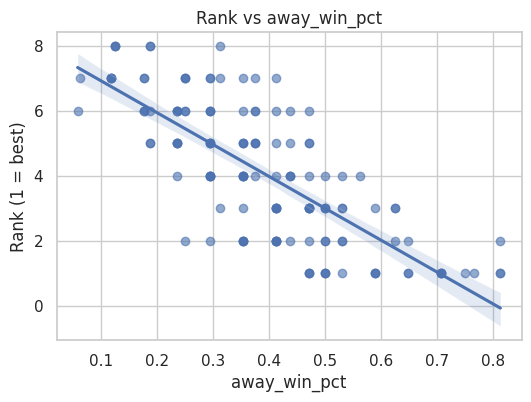

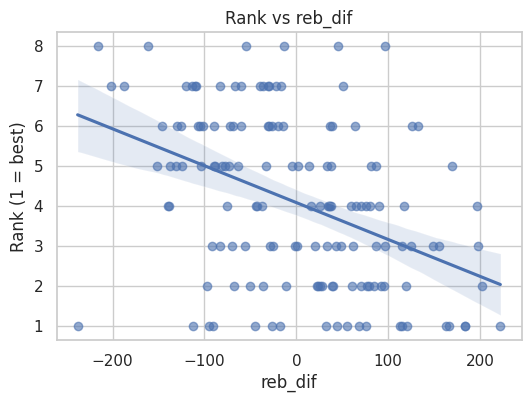

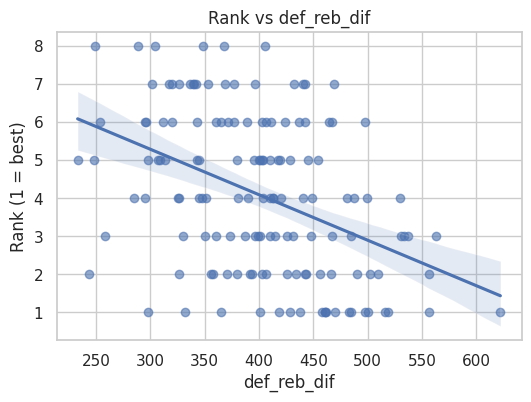

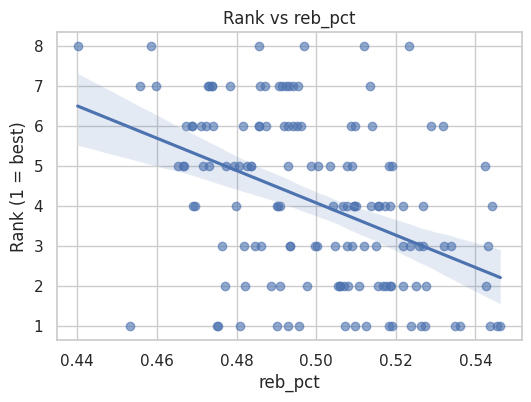

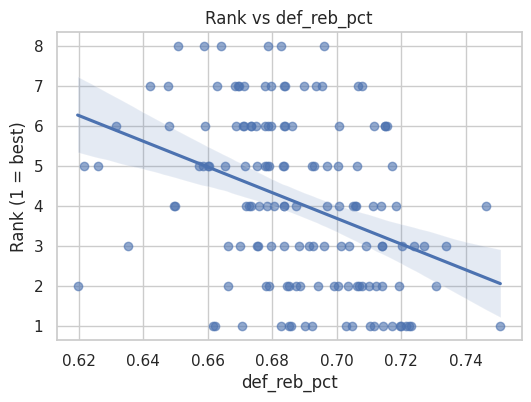

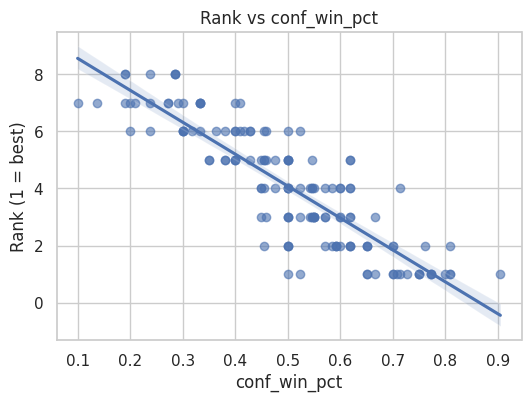

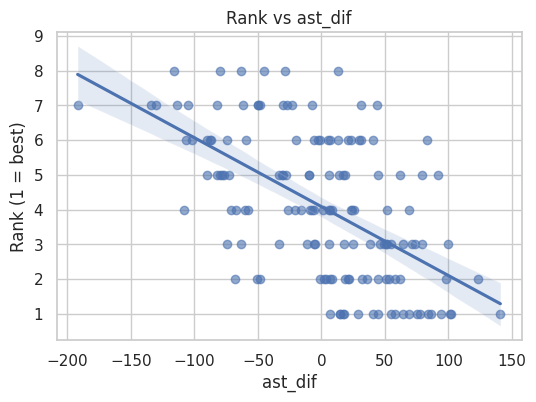

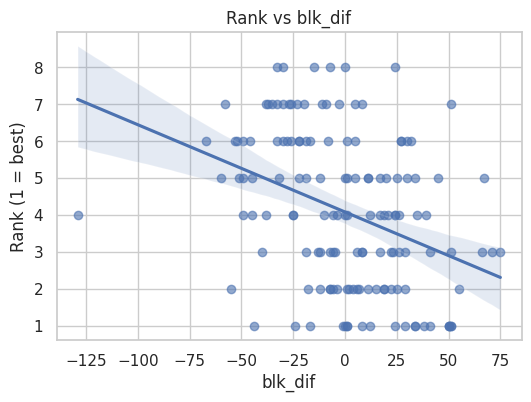

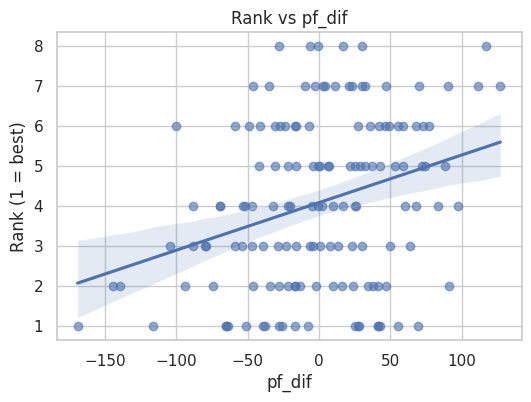

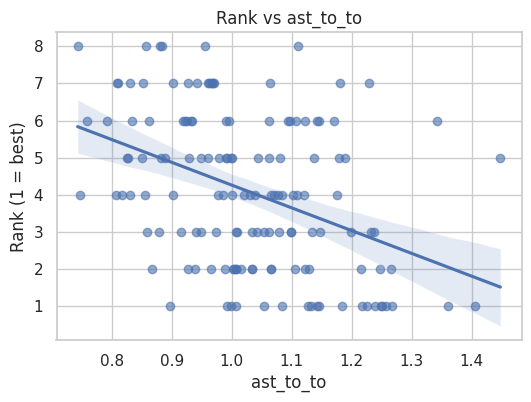

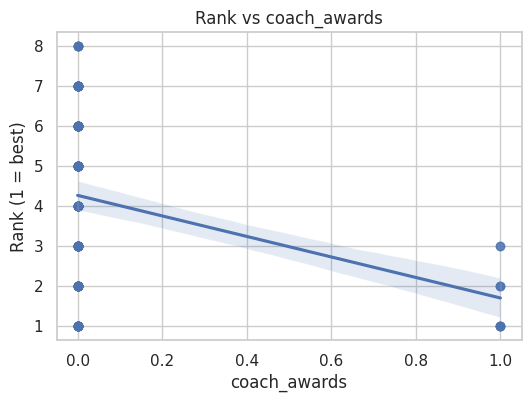

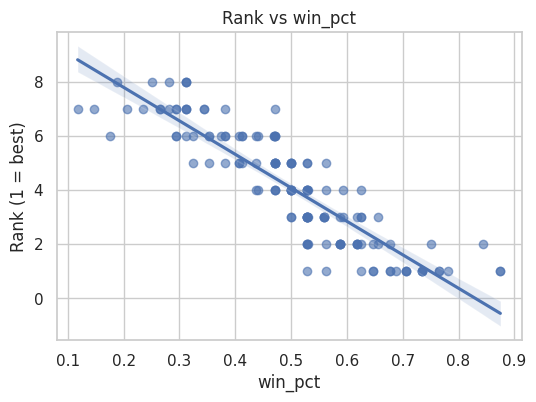

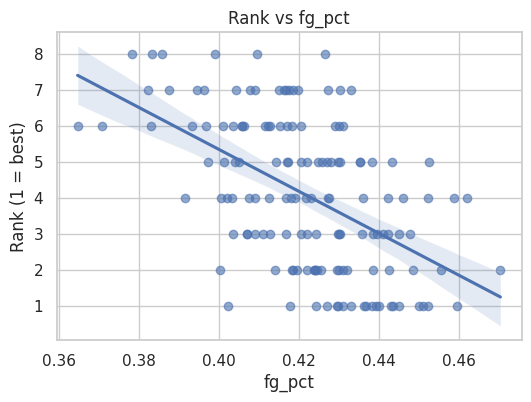

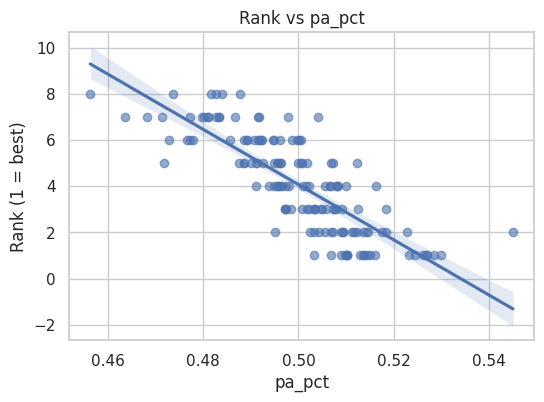

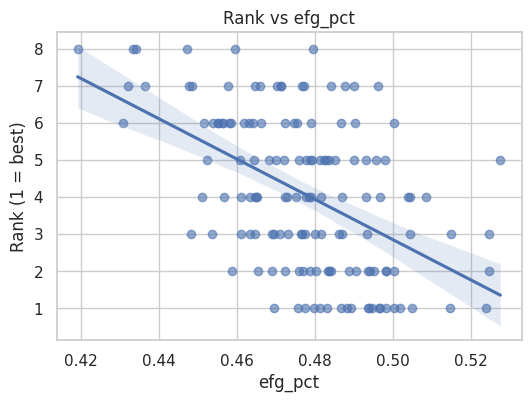

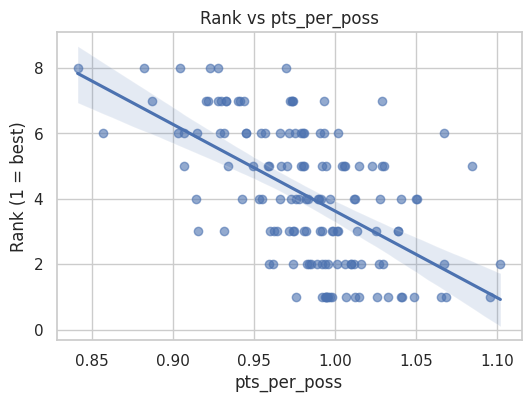

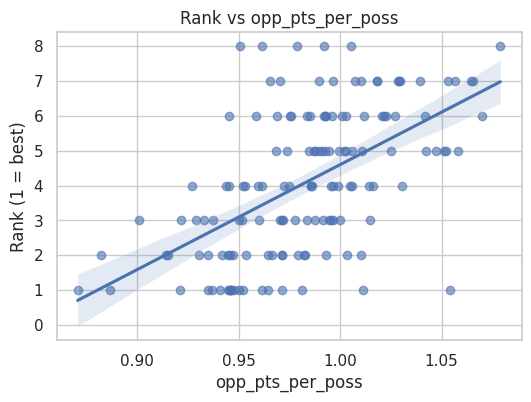

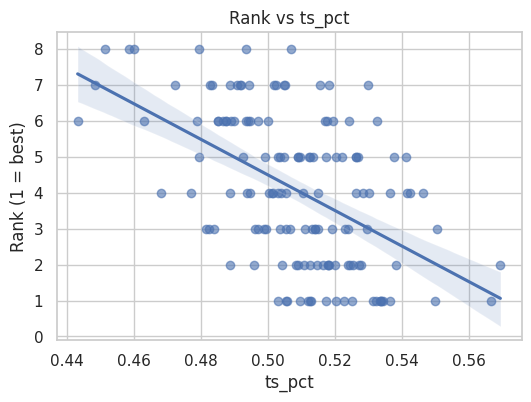

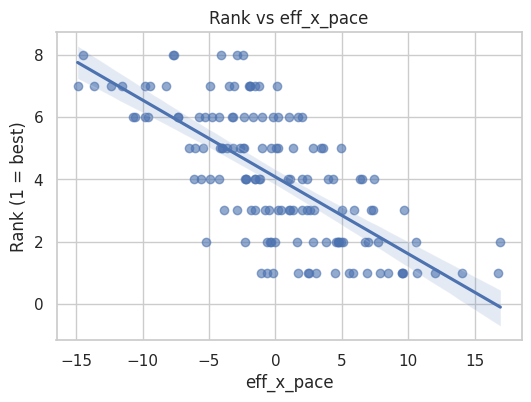

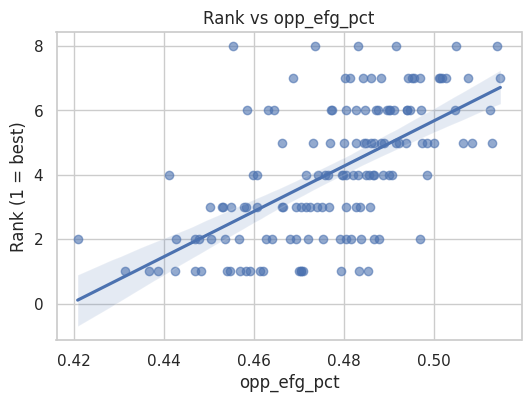

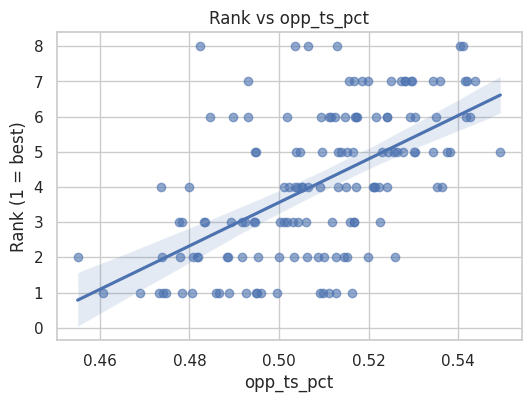

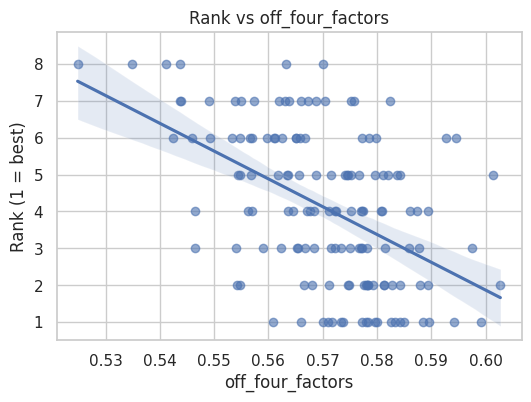

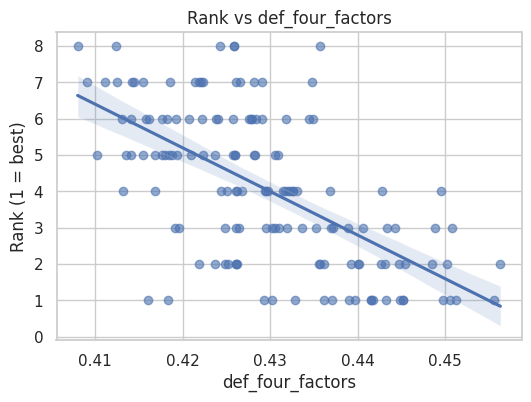

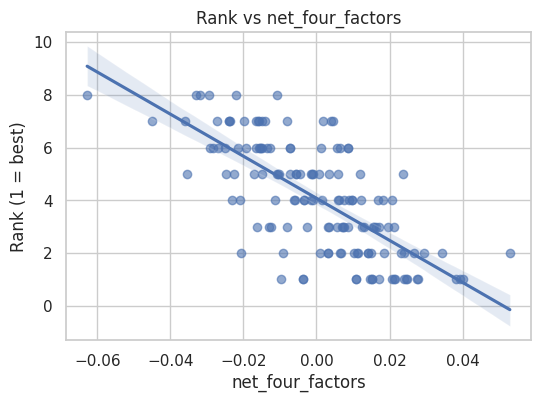

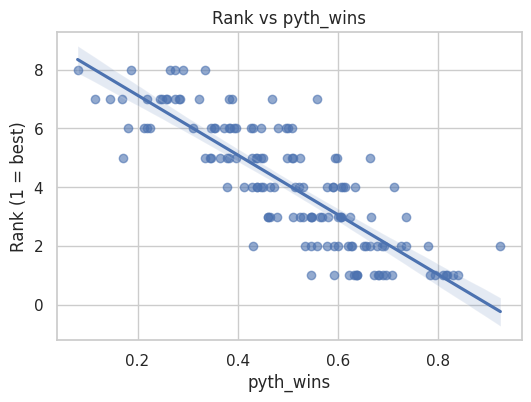

In [38]:
# Visualize the correlations
sns.set(style="whitegrid", context="notebook")

for col in strong_corr.index:
    if col == "rank":
        continue
    
    plt.figure(figsize=(6, 4))
    sns.regplot(x=col, y="rank", data=teams, scatter_kws={"alpha":0.6})
    plt.title(f"Rank vs {col}")
    plt.xlabel(col)
    plt.ylabel("Rank (1 = best)")
    plt.show()


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Most relevant features based on correlation analysis and domain knowledge
selected_features_with_strong_corr = [
    "player_awards",
    "net_rating", # or pa_pct
    "off_eff",
    "def_eff",
    "home_win_pct",
    "away_win_pct",
    "reb_dif", # or reb_pct
    "conf_win_pct",
    "ast_dif", # or ast_to_to
    "blk_dif",
    "pf_dif",
    "coach_awards",
    "efg_pct", # or opp_efg_pct
    "win_pct",
    "pts_per_poss",
    "ts_pct",
    "eff_x_pace",
    "net_four_factors", # or off_four_factors and def_four_factors
    "pyth_wins"
]

# Calculate VIF to validate that the selected features are not multicollinear with each other (VIF <= 10)
vif_data = pd.DataFrame()
vif_data["Feature"] = selected_features_with_strong_corr
vif_data["VIF"] = [variance_inflation_factor(teams[selected_features_with_strong_corr].values, i) 
                   for i in range(len(selected_features_with_strong_corr))]

print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

# Apply RFE (Recursive Feature Elimination) as a wrapper method to further refine the final feature set
X = teams[selected_features_with_strong_corr]
y = teams['rank']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rfe = RFE(RandomForestRegressor(random_state=42))
rfe.fit(X_scaled, y)

final_features = [selected_features_with_strong_corr[i] 
                  for i in range(len(selected_features_with_strong_corr)) 
                  if rfe.support_[i]]

# Show results
print(f"\nRFE selected {len(final_features)} features:")
for feat in final_features:
    print(f"  - {feat}")

ranking = pd.DataFrame({
    'Feature': selected_features_with_strong_corr,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("\nRanking (1 = selected):")
print(ranking.to_string(index=False))

# Save the selected features for modeling
columns_to_save = ['tmID', 'year', 'rank', 'franchID', 'confID'] + selected_features_with_strong_corr

teams[columns_to_save].to_csv('../dataset_for_modeling/features_for_ranking.csv', index=False)


/home/mguerrinha/FEUP/1meic/AC/venv/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/mguerrinha/FEUP/1meic/AC/venv/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/mguerrinha/FEUP/1meic/AC/venv/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


         Feature          VIF
         win_pct          inf
    away_win_pct          inf
    home_win_pct          inf
         off_eff 77489.326361
         def_eff 68299.552690
          ts_pct 12352.817069
         efg_pct  4979.307687
    pts_per_poss  4219.971509
       pyth_wins   675.781515
      eff_x_pace   363.090963
      net_rating    73.129366
    conf_win_pct    68.092498
net_four_factors    10.163317
         ast_dif     2.610685
         reb_dif     2.588444
   player_awards     2.433738
          pf_dif     1.984002
         blk_dif     1.895017
    coach_awards     1.314924

RFE selected 9 features:
  - net_rating
  - def_eff
  - conf_win_pct
  - pf_dif
  - efg_pct
  - win_pct
  - pts_per_poss
  - ts_pct
  - pyth_wins

Ranking (1 = selected):
         Feature  Ranking
      net_rating        1
         def_eff        1
    conf_win_pct        1
          ts_pct        1
         efg_pct        1
         win_pct        1
    pts_per_poss        1
          pf_dif    

### Features for the Third Problem

#### Coach of the Year Award Selected Features

In [48]:
coach_feature_selection_columns = [
    # Identifiers
    'coachID', 'year', 'tmID', 'franchID', 'confID',
    
    # Target
    'won_coy',
    
    # Coach performance
    'won_coach', 'lost_coach', 'win_percentage', 'total_games', 'stint',
    'post_wins', 'post_losses', 'playoff_games', 'playoff_win_pct', 'made_playoffs',
    
    # Team performance
    'rank', 'confW', 'confL', 'conference_win_pct',
    'homeW', 'homeL', 'home_win_pct',
    'awayW', 'awayL', 'away_win_pct', 'home_advantage',
    
    # Team stats
    'o_pts', 'd_pts', 'point_differential',
    'offensive_efficiency', 'defensive_efficiency', 'GP', 'attend',
    
    # Playoff progression
    'playoff', 'firstRound', 'semis', 'finals',
    
    # Improvement metrics (MOST IMPORTANT!)
    'prev_year_wins', 'prev_year_win_pct', 
    'win_improvement', 'win_pct_improvement',
    'team_prev_wins', 'team_win_improvement'
]

coach_features_df = coaches_full[coach_feature_selection_columns].copy()

# Save full feature dataset for Coach of the Year modeling
coach_features_df.to_csv('../dataset_for_modeling/coach_of_year_features.csv', index=False)
print(f"Full feature dataset saved: {coach_features_df.shape}")

# Analyze feature distributions for COY winners vs non-winners
coy_winners = coach_features_df[coach_features_df['won_coy'] == 1]
non_coy = coach_features_df[coach_features_df['won_coy'] == 0]

print("\n=== COACH OF THE YEAR ANALYSIS ===")
print(f"Winners: {len(coy_winners)}, Non-winners: {len(non_coy)}")
print(f"\nKey Insights:")
print(f"- Average wins (COY): {coy_winners['won_coach'].mean():.1f} vs {non_coy['won_coach'].mean():.1f}")
print(f"- Win % (COY): {coy_winners['win_percentage'].mean():.3f} vs {non_coy['win_percentage'].mean():.3f}")
print(f"- Average rank (COY): {coy_winners['rank'].mean():.1f} vs {non_coy['rank'].mean():.1f}")
print(f"- Playoff rate (COY): {coy_winners['made_playoffs'].mean():.1%} vs {non_coy['made_playoffs'].mean():.1%}")
print(f"- Win improvement (COY): {coy_winners['win_improvement'].mean():.1f} vs {non_coy['win_improvement'].mean():.1f}")

Full feature dataset saved: (162, 44)

=== COACH OF THE YEAR ANALYSIS ===
Winners: 10, Non-winners: 152

Key Insights:
- Average wins (COY): 22.0 vs 14.2
- Win % (COY): 0.659 vs 0.478
- Average rank (COY): 1.7 vs 4.3
- Playoff rate (COY): 100.0% vs 52.0%
- Win improvement (COY): 6.5 vs -1.4


#### Most Improved Player Award Selected Features

In [49]:
feature_columns = [
    # Identifiers
    'playerID', 'year', 'tmID', 'stint', 'pos',
    
    # Target
    'won_mip',
    
    # Current season stats
    'GP', 'GS', 'minutes', 'points', 'rebounds', 'assists', 'steals', 'blocks', 'turnovers',
    'ppg', 'rpg', 'apg', 'spg', 'bpg', 'mpg', 'topg',
    
    # Shooting stats
    'fgMade', 'fgAttempted', 'fg_pct',
    'ftMade', 'ftAttempted', 'ft_pct',
    'threeMade', 'threeAttempted', 'three_pct',
    
    # Advanced metrics
    'usage_rate', 'true_shooting', 'ast_to_ratio',
    
    # Previous year stats
    'prev_ppg', 'prev_rpg', 'prev_apg', 'prev_spg', 'prev_bpg', 'prev_mpg',
    'prev_GP', 'prev_GS', 'prev_fg_pct', 'prev_ft_pct', 'prev_three_pct',
    
    # Improvement metrics (MOST IMPORTANT!)
    'ppg_improvement', 'rpg_improvement', 'apg_improvement', 
    'spg_improvement', 'bpg_improvement', 'mpg_improvement',
    'ppg_pct_change', 'rpg_pct_change', 'apg_pct_change', 'mpg_pct_change',
    'gs_improvement', 'GP_improvement',
    'fg_pct_improvement', 'ft_pct_improvement', 'three_pct_improvement',
    'usage_rate_improvement', 'true_shooting_improvement',
    
    # Team context
    'won', 'lost', 'team_win_pct', 'playoff', 'rank', 'confID',
    'made_playoffs',
    
    # Bio data
    'height', 'weight'
]

mip_features_df = player_features[feature_columns].copy()

# Save full feature dataset for Most Improved Player modeling
mip_features_df.to_csv('../dataset_for_modeling/most_improved_player_features.csv', index=False)
print(f"Full feature dataset saved: {mip_features_df.shape}")


# Filter to only players with previous year data
mip_with_history = mip_features_df[mip_features_df['prev_ppg'].notna()].copy()

mip_winners = mip_with_history[mip_with_history['won_mip'] == 1]
non_mip = mip_with_history[mip_with_history['won_mip'] == 0]

print("\n=== MOST IMPROVED PLAYER ANALYSIS ===")
print(f"Winners (with history): {len(mip_winners)}, Non-winners: {len(non_mip)}")
print(f"\nKey Insights:")
print(f"- PPG improvement (MIP): {mip_winners['ppg_improvement'].mean():.2f} vs {non_mip['ppg_improvement'].mean():.2f}")
print(f"- PPG % change (MIP): {mip_winners['ppg_pct_change'].mean():.1f}% vs {non_mip['ppg_pct_change'].mean():.1f}%")
print(f"- Minutes improvement (MIP): {mip_winners['mpg_improvement'].mean():.2f} vs {non_mip['mpg_improvement'].mean():.2f}")
print(f"- Games started improvement (MIP): {mip_winners['gs_improvement'].mean():.1f} vs {non_mip['gs_improvement'].mean():.1f}")
print(f"- Previous PPG (MIP): {mip_winners['prev_ppg'].mean():.2f} vs {non_mip['prev_ppg'].mean():.2f}")


Full feature dataset saved: (1876, 71)

=== MOST IMPROVED PLAYER ANALYSIS ===
Winners (with history): 8, Non-winners: 1313

Key Insights:
- PPG improvement (MIP): 6.40 vs -0.38
- PPG % change (MIP): 163.1% vs 15.2%
- Minutes improvement (MIP): 13.02 vs -0.86
- Games started improvement (MIP): 23.4 vs -0.8
- Previous PPG (MIP): 4.72 vs 7.17


#### Most Valuable Player Award Selected Features

In [53]:
feature_columns = [
    # Identifiers
    'playerID', 'year', 'tmID', 'stint', 'pos',
    
    # Target
    'won_mvp',
    
    # Current season stats
    'GP', 'GS', 'minutes', 'points', 'rebounds', 'assists', 'steals', 'blocks', 
    'turnovers', 'PF',
    'ppg', 'rpg', 'apg', 'spg', 'bpg', 'mpg', 'topg',
    
    # Shooting stats
    'fgMade', 'fgAttempted', 'fg_pct',
    'ftMade', 'ftAttempted', 'ft_pct',
    'threeMade', 'threeAttempted', 'three_pct',
    
    # Advanced metrics
    'usage_rate', 'true_shooting', 'ast_to_ratio', 'per_approx',
    
    # Playoff stats
    'made_playoffs', 'PostGP', 'PostPoints', 'PostRebounds', 'PostAssists',
    'playoff_ppg', 'playoff_rpg', 'playoff_apg',
    
    # Previous year stats
    'prev_ppg', 'prev_rpg', 'prev_apg', 'prev_per_approx',
    'prev_fg_pct', 'prev_true_shooting',
    
    # Improvement metrics
    'ppg_improvement', 'rpg_improvement', 'apg_improvement', 'per_approx_improvement',
    
    # Experience
    'years_experience',
    
    # Team context (CRITICAL FOR MVP!)
    'won', 'lost', 'team_win_pct', 'playoff', 'rank', 'confID',
    'o_pts', 'd_pts', 'team_point_diff',
    
    # Bio data
    'height', 'weight'
]

mvp_features_df = player_features[feature_columns].copy()

# Save full feature dataset for Most Valuable Player modeling
mvp_features_df.to_csv('../dataset_for_modeling/most_valuable_player_features.csv', index=False)
print(f"Full feature dataset saved: {mvp_features_df.shape}")

# Analyze feature distributions for MVP winners vs non-winners
mvp_winners = mvp_features_df[mvp_features_df['won_mvp'] == 1]
non_mvp = mvp_features_df[mvp_features_df['won_mvp'] == 0]

print("\n=== MOST VALUABLE PLAYER ANALYSIS ===")
print(f"Winners: {len(mvp_winners)}, Non-winners: {len(non_mvp)}")
print(f"\nKey Insights:")
print(f"- PPG (MVP): {mvp_winners['ppg'].mean():.2f} vs {non_mvp['ppg'].mean():.2f}")
print(f"- RPG (MVP): {mvp_winners['rpg'].mean():.2f} vs {non_mvp['rpg'].mean():.2f}")
print(f"- APG (MVP): {mvp_winners['apg'].mean():.2f} vs {non_mvp['apg'].mean():.2f}")
print(f"- BPG (MVP): {mvp_winners['bpg'].mean():.2f} vs {non_mvp['bpg'].mean():.2f}")
print(f"- PER approx (MVP): {mvp_winners['per_approx'].mean():.2f} vs {non_mvp['per_approx'].mean():.2f}")
print(f"- Team win% (MVP): {mvp_winners['team_win_pct'].mean():.3f} vs {non_mvp['team_win_pct'].mean():.3f}")
print(f"- Playoff rate (MVP): {mvp_winners['made_playoffs'].mean():.1%} vs {non_mvp['made_playoffs'].mean():.1%}")

Full feature dataset saved: (1876, 66)

=== MOST VALUABLE PLAYER ANALYSIS ===
Winners: 10, Non-winners: 1866

Key Insights:
- PPG (MVP): 19.88 vs 6.09
- RPG (MVP): 7.80 vs 2.79
- APG (MVP): 2.97 vs 1.37
- BPG (MVP): 1.71 vs 0.32
- PER approx (MVP): 22.40 vs 6.37
- Team win% (MVP): 0.679 vs 0.495
- Playoff rate (MVP): 90.0% vs 43.7%
